# Machine Learning Algorithms From Scratch

## Outline

- [Intro](#outline): Context and setup
  - [0.1](#introduction): Introduction
  - [0.2](#setup): Setup
- [Section 1](#section-1-linear-models): Linear models
  - [1.1](#11-ordinary-least-squares) Ordinary least squares
  - [1.2](#12-ridge-regression) Ridge regression
  - [1.3](#13-lasso-regression) Lasso regression
- [Section 2](#section-2-classification-models): Classification models
  - [2.1](#21-knn-classifier) kNN classifier
  - [2.2](#22-logistic-regression) Logistic regression
  - [2.3](#23-rf) Random forest
  - [2.4](#24-svm) Support vector machine (SVM) 

## Introduction [^](#outline)

The following work is based upon a previous MSc coursework piece. The aim is to implement standard machine learning models using just NumPy and native Python. The Python files have been organised into two folders, `models` and `tools`. Models contains a file for each model with all necessary functions. The tools folder contains various functions for key statistics and numerous cross-validation tools for tuning the models. The folder `derivations` contains a series of markdown files, one for each model, providing the mathematical derivations for each model. This notebook is designed to demonstrate the use of the custom made models and to make direct comparisons between the models' outputs and that of the industry standard scikit-learn packages. We will see that the custom made models acheive comparable results. This notebook imports simple datasets from Kaggle (no prior download needed) and tunes the models. This work should **not** be interpreted as serious data-science investigative work, but is instead suppose to demonstrate the validity of the custom models.



<a name="setup"></a>
## Setup [^](#outline)

Here we load the necessary packages for the entire notebook.

In [1]:
# Standard imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import random

# Custom made imports

import models.ols
import models.ridge
import models.lasso
import models.knn
import models.logistic
import tools.statistics
import tools.preprocessing
import tools.cross_validation

# Sklearn models for comparison

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, recall_score, precision_score, f1_score, log_loss
from sklearn.datasets import fetch_california_housing, load_breast_cancer

# Create a seed for any random number generators to ensure reproducibility
seed = 123

## Section 1: Linear Models [^](#outline)


In order to compare our linear models, we will look at one of sklearn's datasets: the california housing dataset. This contains various predictors such as median income of household, age of house and average number of rooms for different regions in California. The target variable is the median house price in each region. The dataset is known to be clean so we omit any data cleaning or analysis as we are simply looking to compare our models. We load the data below.

In [4]:
# Load the data
data = fetch_california_housing(as_frame=True)

# Separate target variable
X = data.data      # DataFrame with named columns
y = data.target    # Series, target variable (median house price)

# Use an 80/20 train/test split
X, X_test, y, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)


## 1.1 Ordinary least squares  [^](#outline)

We fit both OLS models below and store their coefficients.

In [5]:
# Custom model first

# Add an intercept term to our model matrix
N = X.shape[0]
X_int = np.hstack([np.ones((N,1)), X])

# Obtain the coefficients and predicted response
beta = models.ols.coefficients(X_int, y)
y_pred = models.ols.predict(X_int, beta)

# Compute the R^2 squared score using our custom function
r2_score_train = tools.statistics.R_squared(y, y_pred)

# Repeat the process on the test set:
N = X_test.shape[0]
X_test_int = np.hstack([np.ones((N,1)), X_test])
y_pred_test = models.ols.predict(X_test_int, beta)
r2_score_test = tools.statistics.R_squared(y_test, y_pred_test)

# Fit the sklearn model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


We now compare the $R^2$ scores on both the test and training data and also the model coefficients.

In [6]:
print(f'Absolute difference in intercept terms: {abs(model.intercept_-beta[0]) : .3}')
print(f'Absolute difference in remaining coefficient terms: \n {abs(model.coef_-beta[1:]) }')
print(f'Absolute difference in R^2 score on train set: {abs(r2_score(y, model.predict(X)) - r2_score_train) : .3}')
print(f'Absolute difference in R^2 score on test set: {abs(r2_score(y_test, model.predict(X_test)) - r2_score_test) : .3}')

Absolute difference in intercept terms:  1.07e-13
Absolute difference in remaining coefficient terms: 
 [1.22124533e-14 4.01415012e-15 1.95399252e-14 1.48103751e-13
 1.09839844e-16 1.30971622e-16 5.55111512e-15 2.05391260e-15]
Absolute difference in R^2 score on train set:  1.11e-16
Absolute difference in R^2 score on test set:  2.33e-15


We observe that the difference in our coefficients is less than `1e-12` for all estimates. We move on to comparing the ridge regression model now.

<a name="ridge"></a>
## 1.2 Ridge Regression[^](#outline)

We will now compare our ridge model with sklearn's. We'll standardise the data this time as is standard practice when employing ridge regression. A worthwhile note: unlike sklearn's standardise function which stores the mean and standard deviation of the training data and subsequently uses this to standardise the test set, we will not do this and instead standardise both sets separately. In practice, the difference between such approaches is small and it will not invalidate our comparison of coefficients between the two models since the inputted data will be the same. We will also create 5 folds to employ cross-validation when tuning the ridge parameter.

In [7]:
# Standardise data using custom function.
X = tools.preprocessing.standardise(X)
X_test = tools.preprocessing.standardise(X_test)
y = tools.preprocessing.standardise(y)
y_test = tools.preprocessing.standardise(y_test)

# Create the folds
folds = np.array_split(np.arange(len(y)), 5)

Below we employ 5-fold cross validation and perform a grid search over the interval $[0,5000]$ in increments of size $50$ for both our custom model and sklearn. We produce side by side plots of the mean squared error for these different values of the hyperparameter. To avoid confusion, we will refer to our custom model's parameter as $\lambda$ and sklearn's parameter as $\alpha$.

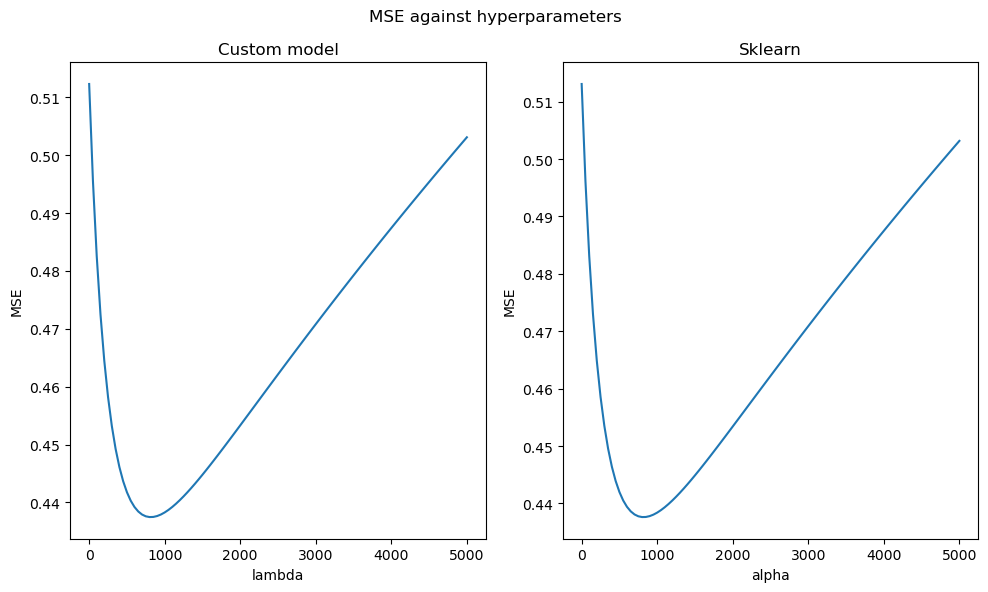

In [8]:
# Perform a simple grid search for the ridge parameter lambda in the interval [0,5000].
lam = np.linspace(0,5000,101)
lam_scores = np.zeros(len(lam))
for i in range(len(lam)):
    lam_scores[i] = tools.cross_validation.cross_val_score(X, y, folds, model_type='ridge', lam=lam[i])

# Repeat the grid search using sklearn
alpha = np.linspace(0,5000,101)
alpha_scores = np.zeros(len(alpha))
for i in range(len(alpha)):
    model = Ridge(alpha=alpha[i])
    alpha_scores[i] = -np.mean(cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error'))

# Produce a plot
fig, ax = plt.subplots(1,2, figsize=(10,6), tight_layout=True)
ax[0].plot(lam, lam_scores)
ax[0].set_title('Custom model')
ax[0].set_xlabel('lambda')
ax[0].set_ylabel('MSE')

ax[1].plot(alpha, alpha_scores)
ax[1].set_title('Sklearn')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('MSE')

plt.suptitle('MSE against hyperparameters')
plt.show()

The above plots appear identical, as we expect. Below we print the optimum values found.

In [9]:
# Find optimum lambda
lam_optimum = lam[np.argmin(lam_scores)]
print(f'MSE is minimised when lambda is {lam_optimum : .3g}')

# Find optimum alpha
alpha_optimum = alpha[np.argmin(alpha_scores)]
print(f'MSE is minimised when alpha is {alpha_optimum : .3g}')

MSE is minimised when lambda is  800
MSE is minimised when alpha is  800


We will now compare the differences in the coefficients and both the $R^2$ and mean squared errors on the test set predictions.

In [ ]:
# Obtain the metrics for the custom model
beta = models.ridge.coefficients(X, y, lam_optimum)
y_pred = models.ridge.predict(X_test, beta)
r2_score_custom = tools.statistics.R_squared(y_test, y_pred)
mse_custom = tools.statistics.MSE(y_test, y_pred)

# Obtain the metrics for the sklearn model
model = Ridge(alpha=alpha_optimum, fit_intercept=False)
model.fit(X,y)
y_pred = model.predict(X_test)
r2_score_sklearn = r2_score(y_test, y_pred)
mse_sklearn = mean_squared_error(y_test, y_pred)

# Print the differences between them
print(f'Difference between coefficients: \n {abs(beta - model.coef_)}')
print(f'Difference in R2 score: {abs(r2_score_custom-r2_score_sklearn) : .3}')
print(f'Difference in MSE: {abs(mse_custom-mse_sklearn) :.3}')

Difference between coefficients: 
 [1.11022302e-16 2.22044605e-16 7.49400542e-16 8.32667268e-17
 4.81385765e-17 8.32667268e-17 1.60982339e-15 1.94289029e-15]
Difference in r2 score:  1.11e-16
Difference in MSE: 1.67e-16


Again we see that all of the differences are less than `1e-14` demonstrating an excellent comparison.

## 1.3 Lasso Regression[^](#outline)

We now repeat the same process as we did for the ridge model but with the lasso model instead.

In [75]:
# Scan over a range of values for lambda
lam = np.linspace(0.001,0.1,100)
lam_scores = np.zeros(len(lam))

for i in range(len(lam)):
    lam_scores[i] = tools.cross_validation.cross_val_score(X, y, folds, model_type='lasso', lam=lam[i], max_iters=10000, learning_rate=1e-1, tol=1e-3)
lam_scores

Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converged before max iterations
Converge

array([0.49600447, 0.48454022, 0.4735836 , 0.46334935, 0.45397839,
       0.44548407, 0.43786922, 0.43115239, 0.42297506, 0.41758002,
       0.41433841, 0.41165882, 0.41007257, 0.40954537, 0.40974232,
       0.41045509, 0.41218636, 0.41477713, 0.4154643 , 0.41679523,
       0.41939329, 0.42064288, 0.42018952, 0.42286477, 0.42354217,
       0.42620506, 0.42926469, 0.43108985, 0.43014473, 0.4329809 ,
       0.43423761, 0.43713217, 0.43682963, 0.43801788, 0.43972846,
       0.44232508, 0.44475313, 0.44819488, 0.44785829, 0.45051588,
       0.45229229, 0.45476952, 0.45694819, 0.45906453, 0.46153647,
       0.46430038, 0.46679104, 0.46894519, 0.47204235, 0.47480329,
       0.47766297, 0.47989208, 0.48253266, 0.48542509, 0.488856  ,
       0.49065856, 0.49143171, 0.49189758, 0.49192892, 0.49257301,
       0.49311779, 0.49344671, 0.49344407, 0.49350162, 0.49439782,
       0.49419388, 0.49484609, 0.49572283, 0.4961093 , 0.49659952,
       0.49730472, 0.4972094 , 0.4981034 , 0.49850189, 0.49869

In [85]:
lam_optimum = lam[np.argmin(lam_scores)]
print(f'Optimum choice of lambda: {lam_optimum :.3f}')

Optimum choice of lambda: 0.014


In [ ]:
# Scan over a range of values for alpha
alpha = np.linspace(0.001,0.1,100)
alpha_scores = np.zeros(len(alpha))

for i in range(len(alpha)):
    model = Lasso(alpha=alpha[i])
    alpha_scores[i] = np.mean(cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5))

alpha_optimum = alpha[np.argmax(alpha_scores)]
print(f'Optimum choice of alpha: {alpha_optimum}')

Optimum choice of alpha: 0.015


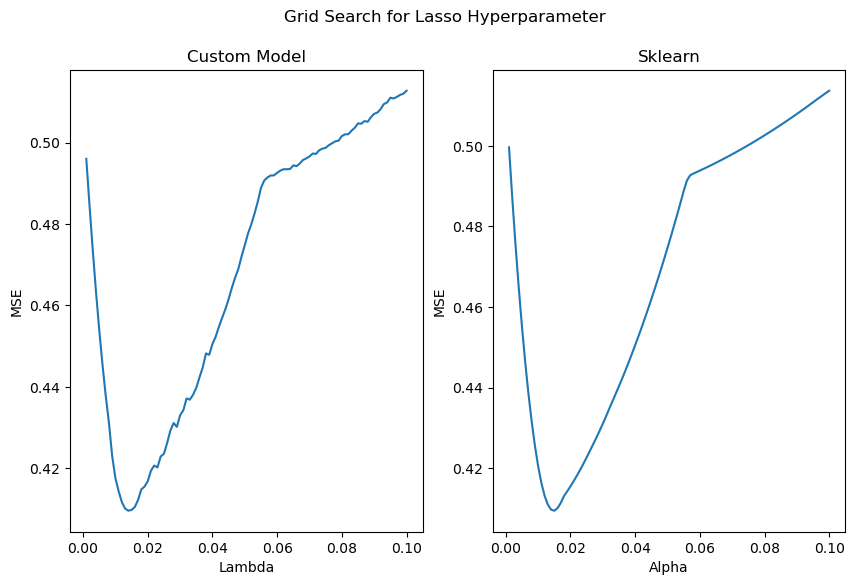

In [77]:
fig, ax = plt.subplots(1,2, figsize=(10,6))

ax[0].plot(lam, lam_scores)
ax[0].set_title('Custom Model')
ax[0].set_xlabel('Lambda')
ax[0].set_ylabel('MSE')

ax[1].plot(alpha, -alpha_scores)
ax[1].set_title('Sklearn')
ax[1].set_xlabel('Alpha')
ax[1].set_ylabel('MSE')

plt.suptitle('Grid Search for Lasso Hyperparameter')

plt.tight_layout
plt.show()

The above plot shows our custom model is indeed converging to similar results as sklearn. To provide a more thorough comparison, we will examine the difference in size of the model coefficients.

In [102]:
# Obtain the metrics for the custom model
beta = models.lasso.coefficients(X, y, lam_optimum, learning_rate=5e-1, tol=1e-4, max_iters=100000)

# Obtain the metrics for the sklearn model
model = Lasso(alpha=alpha_optimum, fit_intercept=False)
model.fit(X,y)

# Print the differences between them
print(f'Difference between coefficients: \n {abs(beta - model.coef_)}')

Failed to converge before max iterations reached
Difference between coefficients: 
 [0.64661957 0.10712572 0.04095113 0.07278876 0.00815107 0.0211638
 0.62975059 0.58985014]


Unfortunately here are coefficients here do not agree as well with sklearn's. This is largely because of the non-differentiability of the $l_1$ norm which has to be resolved. In our model, we used a simple subgradient method, defining the gradient at 0 to be 0, however sklearn's model is more sophisticated and doesn't use gradient descent, but instead uses coordinate descent in conjuction with soft-thresholding, a technique whereby coefficients close to 0 are snapped to 0. Our simple model is prone to oscillating about 0 depending on the size of the learning rate. This is a known limitation of these methods.

# Section 2: Classification Models [^](#outline)

## 2.1 kNN Classifier [^](#outline)

In this section we implement a k-nearest neighbours function for classification. We first load in the data and standardise it. The standardisation is essential because without it, predictors with larger quantities will always be deemed further away by the Euclidean metric. Upon inspecting the data, we can see that the 1st column is just an index for the sample so we remove this. We then change the diagnosis columns to 0's and 1's. This means that when the probability of a sample being malignant can easily be classified by rounding to the nearest integer.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# Standardise the predictor variables using the mean and std of the training data
X = tools.preprocessing.standardise(X)

# Use an 80/20 train/test split
X, X_test, y, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Define the folds
folds = np.array_split(np.arange(len(y)), 5)

Now we tune the model to the training data.

In [6]:
# Train the model

best_k = tools.cross_validation.choose_best_k(X, y, folds, range(1, 11))
print('best_k:', best_k)

For 1 neighbours, accuracy = 0.945, recall = 0.975, precision = 0.939, f1 = 0.956 
For 2 neighbours, accuracy = 0.941, recall = 0.937, precision = 0.968, f1 = 0.952 
For 3 neighbours, accuracy = 0.956, recall = 0.984, precision = 0.950, f1 = 0.966 
For 4 neighbours, accuracy = 0.956, recall = 0.973, precision = 0.960, f1 = 0.966 
For 5 neighbours, accuracy = 0.956, recall = 0.994, precision = 0.940, f1 = 0.966 
For 6 neighbours, accuracy = 0.965, recall = 0.990, precision = 0.956, f1 = 0.973 
For 7 neighbours, accuracy = 0.958, recall = 0.990, precision = 0.946, f1 = 0.968 
For 8 neighbours, accuracy = 0.965, recall = 0.990, precision = 0.957, f1 = 0.973 
For 9 neighbours, accuracy = 0.956, recall = 0.990, precision = 0.943, f1 = 0.966 
For 10 neighbours, accuracy = 0.963, recall = 0.987, precision = 0.957, f1 = 0.972 
best_k: 6


It appears from the above that the optimal value for $k$ is 1. We note that both recall and F1 scores are also maximised with $k=1$ neighbour. We now train the model with $k=1$ and test it on both the training and the test data.

In [11]:
y_pred = models.knn.predict(X, y, X, k = best_k)
acc, recall, precision, f1 = tools.statistics.classification_score(y, y_pred)
print( f'Training scores: \n Accuracy: {acc : .3f} \n Recall: {recall : .3f} \n Precision {precision : .3f} \n F1-Score : {f1 : .3f}')

y_pred = models.knn.predict(X, y, X_test, k = best_k)
acc, recall, precision, f1 = tools.statistics.classification_score(y_test, y_pred)
print( f'Test scores: \n Accuracy: {acc : .3f} \n Recall: {recall : .3f} \n Precision {precision : .3f} \n F1-Score : {f1 : .3f}')

Training scores: 
 Accuracy:  0.969 
 Recall:  0.989 
 Precision  0.962 
 F1-Score :  0.976
Test scores: 
 Accuracy:  0.965 
 Recall:  0.973 
 Precision  0.973 
 F1-Score :  0.973


The fact that a choice of $k=1$ obtained perfect accuracy on the training data is obvious, and not an interesting result. The fact that it did so on the test data as well is very interesting and impressive.

## Comparison with scikit-learn model

Here, we will fit a KNN classifier using sci-kit learn and measure its performance as compared with our own model.

In [9]:
# Define and fit the model
model = KNeighborsClassifier( n_neighbors = best_k )
model.fit(X, y)
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred ), recall_score(y_test, y_pred), precision_score(y_test, y_pred), f1_score(y_test, y_pred)

(0.9649122807017544,
 0.9726027397260274,
 0.9726027397260274,
 0.9726027397260274)

We see that our model obtains exactly the same as the sci-kit learn model.

<a name="q22"></a>

## 2.2 Logistic Regression [^](#outline)

We will begin by obtaining our logistic model parameter estimates in the same dataset used for the KNN model. We start our algorithm with an initial guess of 0 for all parameters.

In [11]:
parameters, grads, costs = models.logistic.optimise(X, y, learning_rate=1, print_cost=True)

cost after iteration 0: 0.693147
cost after iteration 100: 0.055837
cost after iteration 200: 0.048935
cost after iteration 300: 0.045656
cost after iteration 400: 0.043574
cost after iteration 500: 0.042041
cost after iteration 600: 0.040816
cost after iteration 700: 0.039788
cost after iteration 800: 0.038898
cost after iteration 900: 0.038110
cost after iteration 1000: 0.037401
cost after iteration 1100: 0.036757
cost after iteration 1200: 0.036166
cost after iteration 1300: 0.035620
cost after iteration 1400: 0.035112
cost after iteration 1500: 0.034638
cost after iteration 1600: 0.034194
cost after iteration 1700: 0.033776
cost after iteration 1800: 0.033381
cost after iteration 1900: 0.033007
cost after iteration 2000: 0.032653
cost after iteration 2100: 0.032316
cost after iteration 2200: 0.031995
cost after iteration 2300: 0.031689
cost after iteration 2400: 0.031396
cost after iteration 2500: 0.031116
cost after iteration 2600: 0.030847
cost after iteration 2700: 0.030589
cost

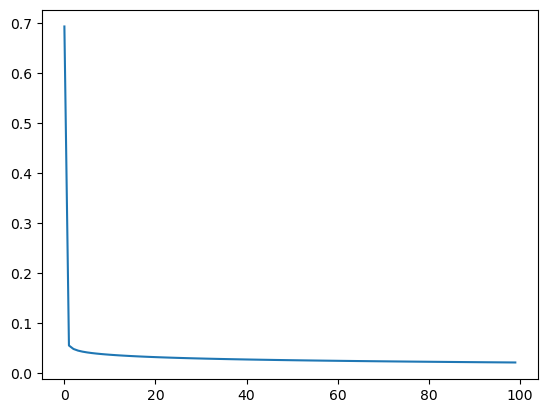

In [12]:
plt.plot(costs)

We now write prediction functions and use them to measure the model's accuracy on both the training set and the test set.

In [13]:
beta = parameters["beta"]
beta_0 = parameters["beta_0"]

y_pred = models.logistic.predict(X, beta, beta_0)
scores_train = tools.statistics.classification_score(y, y_pred)

y_pred = models.logistic.predict(X_test, beta, beta_0)
scores_test = tools.statistics.classification_score(y_test, y_pred)

print(f'Training accuracy: {scores_train[0] :.3f}')
print(f'Training recall: {scores_train[1] :.3f}')
print(f'Training precision: {scores_train[2] :.3f}')
print(f'Training f1-score: {scores_train[3] :.3f}')
print(f'Test accuracy: {scores_test[0] : .3f}')
print(f'Test recall: {scores_test[1] : .3f}')
print(f'Test precision: {scores_test[2] : .3f}')
print(f'Test f1-score: {scores_test[3] : .3f}')

Training accuracy: 0.991
Training recall: 0.996
Training precision: 0.990
Training f1-score: 0.993
Test accuracy:  0.982
Test recall:  1.000
Test precision:  0.973
Test f1-score:  0.986


The accuracy for the training and test sets is shown above respectively. We now use 5-fold cross validation to find the optimum number of samples to use in bagging.

We now scan for the best number of samples. We set the size of each sample to be 2052. This is the size of the data set minus the largest fold.

The results above show that 5 is the optimal number of samples. We now measure the accuracy of our bagging model compared with the previous one. We set the sample size to be equal to the size of the data set.

## Comparison with scikit-learn model

Here, we will fit scikit-learn's logistic model to the same dataset and compare the predictions.

In [14]:
model = LogisticRegression(penalty=None, max_iter=1000, tol=1e-8)
model.fit(X,y)
y_pred = model.predict(X)
print(accuracy_score(y, y_pred))
print(recall_score(y, y_pred))
print(precision_score(y, y_pred))
print(f1_score(y, y_pred))


y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

1.0
1.0
1.0
1.0
0.9824561403508771
1.0
0.9733333333333334
0.9864864864864865


In [15]:
model.coef_, model.intercept_

(array([[ 315.73353494,   74.86761799,  315.96532134,  268.70288579,
         -164.41345514,  432.7213058 , -634.12841685, -250.98759113,
          -41.2232713 , -142.00464927, -491.36977071,  457.16990863,
           10.94487142, -901.61682495, -270.80652603, -257.20801571,
          174.96824301,  -14.80947588,  167.65896942,  828.18346382,
         -759.72273333, -811.53979656, -474.50995239, -726.7420716 ,
          -21.23193114,  546.33463186, -247.6503024 , -548.34513122,
         -179.15257049, -518.97515948]]),
 array([-254.28745528]))

In [16]:
beta.T, beta_0

(array([[ 1.13087638,  1.1055598 ,  1.33060423,  0.8678654 , -0.68152032,
          2.55897053, -3.8482866 , -2.32415138,  0.10560551, -0.143067  ,
         -4.125776  ,  2.72552806, -0.07062686, -5.98617467, -2.15395484,
         -0.74977326,  1.02937353, -0.35170749,  1.36396051,  5.34813971,
         -4.86731494, -5.96504804, -2.67108684, -4.64684666, -0.45358688,
          2.67621276, -2.24209615, -2.85505288, -1.92620594, -3.63183859]]),
 np.float64(-1.2651875731026814))

In [9]:
y_prob = models.logistic.predict_log(X, beta, beta_0)
my_loss = log_loss(y, y_prob)

y_prob = model.predict_proba(X)
sklearn_loss = log_loss(y, y_prob)
print(my_loss, sklearn_loss)

0.05625524180252818 1.3807451083588208e-08


<a name="q23"></a>

## 2.3 Random Forest [^](#outline)

In this section we will train a random forest for classification. The concept of a random forest begins with a simple decision tree. A single decision tree takes an input $\mathbf{x}_i \in \mathbb{R}^p$ and chooses a split $t$ based on a single predictor such that every object is then divided into two categories. Thus our dataset is divided into $\mathbf{x}_i$ s.t. $x_{ij} < t$ and $\mathbf{x}_i$ s.t. $x_{ij}\geq t$ where $t$ is the threshold at which the split is made across the $j^{\text{th}}$ predictor. We now have two sub-regions, call them $X_1, \, X_2$. This process is repeated until a stopping criteria is reached, such as there being less than some number of observations in a single region or a max number of regions is reached. Once we have obtained our regions $X_1, \, X_2, \dots X_s$ we then predict each observation to be the modal response in each region. The optimal split at each stage is defined to be the one which minimises some loss function at that stage. Thus, the decision tree algorithm is <i>greedy</i>. In our case, we will choose to minimise the <i>cross-entropy</i> which, for a given region $X_r$, is given by
$$
-\sum_{k=1}^K p_r^{(k)} \log (1 - p_r^{k}). 
$$
Here, $K$ denotes the number of classes and $k$ the given class an observation belongs too. The probability that an element belongs to class $k$ given it is in region $r$ is given by
$$
p_r^{(k)} = \frac{\sum_{i=1}^n \mathbb{I}_{\mathbf{x}_i \in X_r} \mathbb{I}_{y_i = k}}{\sum_{i=1}^n \mathbb{I}_{\mathbf{x}_i \in X_r}}.
$$
More specifically, we choose the split such that the resulting weighted sum of the cross-entropy across the two new sub-regions (weighted by the number of observations in each sub-region) is reduced maximally.

Once we have a simple decision tree, we can implement <i>bagging</i>. The idea here is that we instead produce $N$ decision trees, each trained on a bootstrapped sample from the original dataset (a random sample from the dataset which allows for replacement). To obtain a prediction, we simply take the mean or modal response from the $N$ trees depending on whether it is a classification or a regression task. A random forest is the same, with the exception that at each split, a random subset of the predictors is chosen from in order to prevent a single predictor from dominating the decision tree.

The data has been loaded previously in the kNN section and we obtained the feature names which is needed as an input for this section.

We now define several functions. The first measures the cross entropy. The second splits the samples given a column to split about and a value for the split. The next function finds the optimum split value given a feature and the one after finds the optimum split for any given data set. This is then all combined together in the `build_tree` function.

In [10]:
def cross_entropy(probs):
    '''
    Computes the cross-entropy given a vector of probabilities

    INPUT:
    probs - an array of probabilities of y belonging to each class. Thus len(probs) is the number of classes

    OUTPUT:
    CE - the cross entropy
    '''

    CE = 0
    for i in range(len(probs)):
        # Avoid log(0)
        if (probs[i]==0):
            CE = 0.
        else:
            CE -= probs[i] * np.log(probs[i])
    return CE

def split_samples(X, y, column, value):
    '''
    Splits the data into two distinct sub-regions about a given column and value

    INPUTS:
    X - an n x p array of observations
    y - an n-vector consisting of the classes that each observation belongs to
    column - the column to perform the split on
    value - the splitting value

    OUTPUTS:
    X_left - the region whose selected column contains values smaller than the split value
    X_right - the region whose selected column contains values larger than or equal to the split value
    y_left - the corresponding classes for X_left
    y_right - the corresponding classes for X_right
    '''
    assert type(column) == int, f'Input column to split_samples is not an integer'
    
    left_region = (X[:,column]<value)

    assert left_region.shape[0] == X.shape[0]
    
    X_left, X_right = X[left_region, :], X[~left_region, :]
    y_left, y_right = y[left_region], y[~left_region]
    
    return X_left, X_right, y_left, y_right

def CE_split_value(X,y,column):
    '''
    Determine the optimum split value for a given column. Only valid for binary classification tasks where y is either 0 or 1

    INPUTS:
    X - an n x p array of the observations
    y - a n-vector of the corresponding classes of the n observations
    column - the column/predictor to be split about

    OUTPUTS:
    CE - the cross entropy after the new split
    split_val - the optimum value to split a given column about
    '''
    
    unique_vals = np.unique(X[:, column])
    assert len(unique_vals) > 1, f"There must be more than one distinct feature value. Given: {unique_vals}."

    CE, split_val = np.inf, None
  
    # Split the values of i-th feature and calculate the cross entropy
    
    for value in unique_vals:
        X_l, X_r, y_l, y_r = split_samples(X, y, column, value)

        # If one of the two sides is empty, skip this split
        
        if (len(y_l) == 0) or (len(y_r) == 0):
            continue
            
        # Obtain probabilities for y belonging to class 0/1 in region l/r
    
        y_l_1 = sum(y_l)
        y_l_0 = len(y_l) - y_l_1
    
        y_r_1 = sum(y_r) 
        y_r_0 = len(y_l) - y_r_1
        
        p_l_0 = y_l_0/(X_l.shape[0])
        p_l_1 = y_l_1/(X_l.shape[0])
        
        p_r_0 = y_r_0/X_r.shape[0]
        p_r_1 = y_r_1/X_r.shape[0]
    
        prob_l = np.array([ p_l_0, p_l_1 ])
        prob_r = np.array([ p_r_0, p_r_1 ])

        # Compute the weighted sum
    
        w_l = len(y_l)/(len(y_l) + len(y_r))
        w_r = 1 - w_l

        # Calculate the cross-entropy for the given split
    
        new_cost = w_l * cross_entropy(prob_l) + w_r * cross_entropy(prob_r)

        # Check if it has indeed reduced the CE
        
        if new_cost < CE:
            CE, split_val = new_cost, value
    
    return CE, split_val

def CE_split(X, y):
    '''
    Chooses the feature to split along which most greatly minimises the CE

    INPUTS:
    X - an n x p array of observations
    y - an n-vector of correpsonding classses, either 0 or 1

    OUTPUT:
    split_column - the optimum column to split along
    split_value - the optimum value for the split
    '''
    
    # Initialize `split_column` to None, so if None returned this means there is no valid split at the current node.

    min_CE_index, split_column, split_val = np.inf, None, 0
    for column in range(X.shape[1]):
    
        # Skip column if samples are not seperable by that column.
        
        if len(np.unique(X[:, column])) < 2:
            continue

        # Obtain the cross entropy and optimum split value for a given column
            
        CE_index, val = CE_split_value(X, y, column)    

        # Update if the new CE is smaller
        
        if CE_index < min_CE_index:
            min_CE_index, split_column, split_val = CE_index, column, val

    return split_column, split_val

def majority_vote(y):
    '''
    Selects the majority class

    INPUTS:
    y - an n-vector containing the classes (either 0 or 1) of the n observations

    OUTPUT:
    the majority class, either 0 or 1
    '''
    return np.argmax(np.bincount(np.array(y, dtype='int')))

def build_tree(X, y, feature_names, depth,  max_depth=10, min_samples_leaf=2):
    '''
    Builds a simple decision tree

    INPUTS:
    X - an n x p array of observations
    y - an n-vecotr of the corresponding binary classes
    feature_names - a list of strings consisting of the feature names
    depth - an index determining what layer of the tree we are in
    min_samples_leaf - the minimum number of observations in a single leaf at any stage
    max_depth - maximum depth of the tree

    OUTPUT:
    A nested dictionary consisting of: the feature name for the split, the index which it is split at, the value for the split at, the classification (None if not a leaf), the left and right subtrees 
    '''
    
    # Include a clause for the cases where (i) no feature, (ii) all labels are the same, (iii) depth exceed, or (iv) X is too small
    if len(np.unique(y))==1 or depth>=max_depth or len(X)<=min_samples_leaf: 
        return {'majority_label': majority_vote(y)}
  
    split_index, split_val = CE_split(X, y)

    # If no valid split at this node, use majority vote.
    
    if split_index is None:
        return {'majority_label': majority_vote(y)}

    X_l, X_r, y_l, y_r = split_samples(X, y, split_index, split_val)
    
    return {
      'feature_name': feature_names[split_index],
      'feature_index': split_index,
      'value': split_val,
      'majority_label': None,
      'left': build_tree(X_l, y_l, feature_names, depth + 1, max_depth, min_samples_leaf),
      'right': build_tree(X_r, y_r, feature_names, depth + 1, max_depth, min_samples_leaf)
  }

We now plot a simple decision tree below.

In [17]:
simple_tree = build_tree(X, y, feature_names, 1)
simple_tree

C:\Users\ccbar\AppData\Local\Temp\ipykernel_3860\142036495.py:18: RuntimeWarning: invalid value encountered in log
  CE -= probs[i] * np.log(probs[i])


{'feature_name': 'n1_radius',
 'feature_index': 0,
 'value': np.float64(5.463677272710677),
 'majority_label': None,
 'left': {'feature_name': 'n1_radius',
  'feature_index': 0,
  'value': np.float64(5.375685952703196),
  'majority_label': None,
  'left': {'feature_name': 'n1_radius',
   'feature_index': 0,
   'value': np.float64(5.107270325892665),
   'majority_label': None,
   'left': {'feature_name': 'n1_radius',
    'feature_index': 0,
    'value': np.float64(4.991131382943025),
    'majority_label': None,
    'left': {'feature_name': 'n1_radius',
     'feature_index': 0,
     'value': np.float64(4.93779794180742),
     'majority_label': None,
     'left': {'feature_name': 'n1_radius',
      'feature_index': 0,
      'value': np.float64(4.929520468047421),
      'majority_label': None,
      'left': {'feature_name': 'n1_radius',
       'feature_index': 0,
       'value': np.float64(4.782045668344655),
       'majority_label': None,
       'left': {'feature_name': 'n1_radius',
     

We now create functions which predict a classification given some data and a function which scores the accuracy of a given tree.

In [11]:
def classify(tree, x):
    '''
    Classifies an observation x using a given tree

    INPUTS:
    tree - a simple decision tree constructed using build_tree
    x - an observation to classify

    OUTPUT:
    0 or 1 - the predicted classification of x
    '''
    
    if tree['majority_label'] is not None: 
        return tree['majority_label']
    else:
        if x[tree['feature_index']] < tree['value']:
            return classify(tree['left'], x)
        else:
            return classify(tree['right'], x)

def predict(tree, X):
    '''
    Predicts the classes of a set of observations X

    INPUTS:
    tree - a simple decision tree made using build_tree
    X - an n x p array of observations

    OUTPUTS:
    an n x 1 array of predicted classifications of the observations
    '''
    
    if len(X.shape) == 1:
        return classify(tree, X)
    else:
        return np.array([classify(tree, x) for x in X])

def tree_score(y_test, y_pred):
    '''
    Measures the accuracy of a given tree

    INPUTS:
    tree - a simple decision tree made using build_tree
    X_test - an n x p array of observations
    y_test - an n x 1 array of corresponding classes

    OUTPUTS:
    acc - the accuracy of the tree's predictions
    recall - the recall of the predictions, i.e. true positive rate or specificity
    precision - the precision of the predictions. i.e. positive predictive rate
    f1_score - the f1_score, i.e. the harmonic mean of recall and precision
    '''

    TP = np.sum( (y_pred == y_test) & (y_test==1) )
    TN = np.sum( (y_pred == y_test) & (y_test==0) )
    FP = np.sum( (y_pred != y_test) & (y_test==0) )
    FN = np.sum( (y_pred != y_test) & (y_test==1) )

    acc = np.mean(y_pred==y_test)
    recall = TP / (TP + FN)
    precision = TP / (TP + FP)
    f1_score = ( 2*recall*precision ) / ( recall + precision ) 
    return acc, recall, precision, f1_score

We now measure our simple tree's accuracy on both the training and testing data.

In [ ]:
y_pred = predict(simple_tree, X)
print(f'Training scores: {tree_score(y, y_pred) }')
y_pred = predict(simple_tree, X_test)
print(f'Test scores: {tree_score(y_test, y_pred) }')

We now define the necessary functions for a Random Forest.

In [12]:
def CE_split_rf(n_features, X, y):
    '''
    Calculates the optimum split for a dataset which minimises the CE based on a random subset of the predictors

    INPUTS:
    n_features - the size of the random subset of the predictors
    X - an n x p array of observations
    y - an n x 1 array of corresponding classifications

    OUTPUTS:
    min_CE_index - the new CE after the optimum split
    best_split_column - the index of the optimal column to split about
    split_val - the optimum value in that column to split about
    '''
    
    # Select the random subset of the predictors

    subset_indices = random.sample(range(X.shape[1]), n_features)

    # Initialise parameters
    
    min_CE, best_split_column, best_split_val = np.inf, 0, 0
    
    for column in subset_indices:
        
        # Skip column if samples are not seperable by that column.
        
        if len(np.unique(X[:, column])) < 2:
            continue

        # Search for the best splitting value for the given column.
        
        CE, split_val = CE_split_value(X, y, column)
        #print(f'For column {column} the CE after optimum splitting in this column is {CE}')
        
        if CE < min_CE:
            min_CE, best_split_column, best_split_val = CE, column, split_val

    return min_CE, best_split_column, best_split_val

def build_tree_rf(n_features, X, y, feature_names, depth,  max_depth=10, min_samples_leaf=2):
    '''
    Constructs a single tree in a random forest. Identical to build_tree except calls CE_split_rf to use a subset of the predictors instead

    INPUTS:
    n_features - the size of the random subset of the predictors
    X - and n x p array of observations
    y - the corresponding n x 1 array of classifications
    feature_names - a list of strings containing the feature names
    depth - a placeholder counting the current depth of the tree
    max_depth - a stopping criteria for when the tree should stop growing
    min_samples_leaf - another stopping criteria. If any given leaf has less observations than this, the split is not performed.

    OUTPUTS:
    A single random forest tree i.e. a dictionary in the same format as the build_tree output
    '''

  # Include a clause for the cases where (i) all lables are the same, (ii) depth exceed (iii) X is too small

    if len(np.unique(y)) == 1 or (depth>=max_depth) or len(X)<min_samples_leaf:
        return {'majority_label': majority_vote(y)}
  
    else:
        # Find the optimum split and split the data
        CE, split_index, split_val = CE_split_rf(n_features, X, y)
        X_l, X_r, y_l, y_r = split_samples(X, y, split_index, split_val)
        
        # If CE is infinity, it means that samples are not seperable by the sampled features.
        # Also return majority label if the next split results in leaves which are too small.
        
        if (CE == np.inf):
            return {'majority_label': majority_vote(y)}

        else:
            return {
            'feature_name': feature_names[split_index],
            'feature_index': split_index,
            'value': split_val,
            'majority_label': None,
            'left': build_tree_rf(n_features, X_l, y_l, feature_names, depth = depth+1, max_depth=max_depth, min_samples_leaf=min_samples_leaf),
            'right': build_tree_rf(n_features, X_r, y_r, feature_names, depth = depth+1, max_depth=max_depth, min_samples_leaf=min_samples_leaf)
       }

Having now defined functions which build a random forest, we now create functions to train one on given data and predict from that.

In [13]:
def train_rf(B, n_features, feature_names, X, y, max_depth=10):
    '''
    Builds a random forest of size B 
    
    INPUTS:
    B - The number of trees to build
    n_features - The number of features in each random subset of predictors in each random forest tree
    feature_names - A list of strings containing the feature names
    X - an n x p array of observations
    y - an n x 1 array of corresponding classifications
    max_depth - the maximum depth of each tree in the random forest

    OUTPUT:
    A list of random forest trees each trained on a different boostrapped sample
    '''
    
    N = X.shape[0] # Number of observations
    training_indices = np.arange(N)
    trees = []

    for _ in range(B):
        
        # Create a bootstrapped sample
        
        sample = np.random.choice(training_indices, N, replace=True)
        X_sample = X[sample, :]
        y_sample = y[sample]

        # Build the tree on this sample and add to the list of trees
        
        tree = build_tree_rf(n_features, X_sample, y_sample, feature_names, depth=1, max_depth=max_depth)
        trees.append(tree)
    
    return trees

def aggregate(decisions):
    '''
    Counts the number of each classification from the trees in a random forest and returns the majority.

    INPUTS:
    decisions - an array of predictions. Should be an the output of classify()

    OUTPUS:
    the majority classification
    '''
    
    count = defaultdict(int)
        
    for decision in decisions:
        count[decision] += 1
            
    return max(count, key=count.get)

def predict_rf(rf, X):
    '''
    Makes a prediction given a random forest of trees in the case of classification.

    INPUTS:
    rf - a random forest, i.e. an output from train_rf
    X - an n x p array of observations to classify

    OUTPUTS:
    an n x 1 array of classifications
    '''

    if len(X.shape) == 1:
        return aggregate([classify(tree, X) for tree in rf])
    else:
        return np.array([aggregate([classify(tree, x) for tree in rf]) for x in X])

We now implement 5 fold cross validation to select the optimal number of trees and the the optimal depth. We use the same folds as in section 2.1.

In [14]:
# Same code as before except it calls rf_score instead

def cross_validation_score_rf(X_train, y_train, folds, B, d, feature_names, n_features):
    '''
    Implements k-folds cross valdiation on the random forest.

    INPUTS:
    X_train - n x p array of training observations
    y_train - n x 1 array of corresponding classifications
    folds - k x n/k array of indices corresponding to the folds
    B - the number of trees in the RF
    d - the max depth of each tree
    feature_names - A list of strings containing the feature names
    n_features - The number of features in each random subset of predictors in each random forest tree

    OUTPUTS:
    The average accuracy of the random forest's predictions across the folds
    '''
    
    scores = []
    for i in range(len(folds)):
        
        # First split the data
        
        val_indexes = folds[i]
        train_indexes = list(set(range(y_train.shape[0])) - set(val_indexes))
    
        X_train_i = X_train[train_indexes, :]
        y_train_i = y_train[train_indexes]

        X_val_i = X_train[val_indexes, :]
        y_val_i = y_train[val_indexes]
        
        # Train a rf using the training data
        
        rf = train_rf(B, n_features, feature_names, X_train_i, y_train_i, max_depth=d,)

        # Obtain predictions and score them based on accuracy
        
        y_pred = predict_rf(rf, X_val_i)
        score_i = tree_score(y_val_i, y_pred)[0] # Use 0 for accuracy, 1 for recall, 2 for precision or 3 for f1-score
        scores.append(score_i)

        # Return the average scores
        ans = np.mean(scores, axis=0)
        
    return ans
    
# Here, B is the number of trees
# Implement a nested for loop to scan over different depths and different numbers of trees

def choose_best_B(X_train, y_train, folds, B_range, d_range, feature_names, n_features):
    '''
    Performs a grid search to find the optimum number of trees whilst also scanning over different maximum depths

    INPUTS:
    X_train - n x p array of training observations
    y_train - n x 1 array of corresponding classifications
    folds - k x n/k array of indices corresponding to the folds
    B_range - an array of values of B to search over
    d_range - an array of values for max_depth to search over
    feature_names - A list of strings containing the feature names
    n_features - The number of features in each random subset of predictors in each random forest tree

    OUTPUTS:
    The optimum choice of B (as measured by highest accuracy) over the given grid
    B_scores - a 2D array of the scores (used for plotting)
    '''
    
    B_scores = np.zeros((len(B_range), len(d_range)))
    
    for i, B in enumerate(B_range):
        
        for j, d in enumerate(d_range):

            B_scores[i,j] = cross_validation_score_rf(X_train, y_train, folds, B, d, feature_names, n_features)
            print(f'For {B} trees with max depth of {d}, the accuracy is: {B_scores[i,j]:.3f}')

    best_B_per_row = [max(B_scores[i,:]) for i in range(len(B_range))]
    best_B_index = np.argmax(best_B_per_row)
    
    return B_range[best_B_index], B_scores

# Here, d is the depth of the trees

def choose_best_d(X_train, y_train, folds, B, d_range, feature_names, n_features):
    '''
    Performs a grid search to find the optimum maximum depth of each tree in the rf

    INPUTS:
    X_train - n x p array of training observations
    y_train - n x 1 array of corresponding classifications
    folds - k x n/k array of indices corresponding to the folds
    B - the number of trees in the random forest
    d_range - an array of values for max_depth to search over
    feature_names - A list of strings containing the feature names
    n_features - The number of features in each random subset of predictors in each random forest tree

    OUTPUTS:
    The optimum choice of max_depth (as measured by highest accuracy) over the given grid
    '''
    d_scores = np.zeros((len(d_range),))
    
    for i, d in enumerate(d_range):
        d_scores[i] = cross_validation_score_rf(X_train, y_train, folds, B, d, feature_names, n_features)
        print(f'For a max depth of {d}, the accuracy is: {d_scores[i]:.3f}')

        best_d_index = np.argmax(d_scores)
    return d_range[best_d_index]

We set the number of features in the random forest to be one third of the number of predictors, as is standard practice. We now tune the number of trees. Since the accuracy converges quickly for random forests, we do not need to scan over a large range of values.

In [ ]:
n_features = round(np.sqrt(X.shape[1]))
best_B, B_scores = choose_best_B(X, y, folds, np.array([10,50,100,200]), np.array([2,5,10,20]), feature_names, n_features)

We now scan over a range of different depths.

In [ ]:
best_d = choose_best_d(X, y, folds, best_B, np.arange(2,31,2), feature_names, n_features)

We now train a random forest on the entire training data set and compare its accuracy with the test set.

In [ ]:
rf = train_rf(100, n_features, feature_names, X, y, max_depth=10)
y_pred = predict_rf(rf, X)
tree_score(y, y_pred)

In [ ]:
y_pred = predict_rf(rf, X_test)
tree_score(y_test, y_pred)

## Comparison with Sci-Kit Learn Model

In [16]:
model = RandomForestClassifier(n_estimators = 100, criterion='entropy', max_depth=10, min_samples_leaf=2, max_features='sqrt')
model.fit(X, y)
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred ), recall_score(y_test, y_pred), precision_score(y_test, y_pred), f1_score(y_test, y_pred)

(0.975, 0.9315068493150684, 1.0, 0.9645390070921985)

<a name="q24"></a>

## 2.4 Support Vector Machine [^](#outline)

In this section we will implement a support vector machine (SVM). The term SVM is often used interchangeably with 3 closely related concepts: the maximal margin classifier, soft margin classifier and a SVM. We will implement a soft margin classifier here.

We start with the idea of a maximal margin classifier which only has a solution when the observed data can be split into two distinct regions by a hyperplane with all observation in one class resting on one side of the plane and the other class on the opposite side. In general, for $p$-dimensional space, where $p$ is the number of predictors, a hyperplane is defined by
$$
\alpha_0 + \alpha_1X_1 + \alpha_2 X_2 + \cdots \alpha_p X_p = 0
$$
It is often more helpful to work with the dot product representation below
$$
\alpha_0 + \boldsymbol{\alpha}\cdot \mathbf{X} = 0
$$
Having defined a hyperplane, we now wish to add the constraint that each observation beloning to a single class falls to one side of the plane. It is helpful to classify our target variable as $y_i\pm1$. Then, if one observation $\mathbf{x}_i$ lies above the plane (by above in this context we mean that is lies on the side of the plane that the vector $\boldsymbol{\alpha}$ points in), then $ \alpha + \mathbf{x}_i \cdot \boldsymbol{\alpha} > 0 $. Likewise, this will be negative if it lies on the other side of the hyperplane. This also explains how our SVM will predict new observations. The predicted response for a new observation $\mathbf{x}' $ is just the sign of $\alpha + \boldsymbol{\alpha} \cdot \mathbf{x}'$. Thus, for all observations in the training set, we wish to impose the constraint
$$
y_i(\alpha + \boldsymbol{\alpha} \cdot \mathbf{x}_i) > 0
$$
Such a hyperplane need not be unique, indeed, there are many. We thus add the further constraint that we wish to maximise the distance between the closest points to the hyperplane. The perpendicular distance from any given observation to the hyperplane is given by
$$
d_i = \frac{|\alpha + \boldsymbol{\alpha}\cdot \mathbf{x}_i|}{||\boldsymbol{\alpha}||}.
$$
Thus, maximising the distance between the closest points to the hyperplane is thus equivalent to
$$
\max_{\alpha, \boldsymbol{\alpha}} M
$$
where $M = 2\min_{i} d_i$ is the *margin*. By inspection, one can see that $M$ depends only on the closest observations on either side of the plane. Further, if $\mathbf{x}^*$ is the closest observation on the positive side of the hyperplane then $M = 2d^*$ where $d^*$ is the perpendicular distance of $\mathbf{x}^*$ from the plane. This is because the minimum distance on the positive side of the plane must equal the that of the minimum distance on the negative side. If it didn't, then one of the distances $d_i$ would be decreased thus leading to a smaller value of $M$ thus making such a scenario not the maximal value of $M$. We thus wish to maximise
$$
M = \frac{2(\alpha + \boldsymbol{\alpha} \cdot \mathbf{x}^*)}{||\boldsymbol{\alpha}||}
$$
subject to the aforementioned constraints. Maximising the above expression is indeed equivalent to the alternative optimisation problem:
$$
\min_{\alpha, \boldsymbol{\alpha} } \frac{1}{2}||\boldsymbol{\alpha}||^2.
$$
This is valid since squaring is a monotonically increasing function. We square the norm and introduce the factor of $1/2$ for algebraic convenience which we will see later on. Now, by definition, each distance must be non-strictly greater than the margin $M$, so
$$
\frac{\alpha + \boldsymbol{\alpha} \cdot \mathbf{x}_i}{||\boldsymbol{\alpha}||} \geq M.
$$
The inequality constraints can safely be multiplied by any scalar without altering the solution to the optimisation problem. We can thus choose $||\boldsymbol{\alpha}||=1/M$ reducing the above to
$$
1 - (\alpha + \boldsymbol{\alpha} \cdot \mathbf{x}_i) \leq 0.
$$
We can solve our optimisation problem now by introducing Lagrange multipliers.

In this section we implement an SVM. We reload the data and instead categorise diagnoses by $1$ or $-1$. The positive outcome corresponds to a positive diagnosis. The data is standardised as if it is not, this will influence the choice of the hyperplane. We define a cost function which we seek to minimise via stochastic gradient descent and then train the model on the data.

In [4]:
# Prepare the data and standardise it
# In this section, we instead use +/- 1 for the diagnosis for ease of use when using SVMs.

tumour_samples = pd.read_csv('C://Users/ccbar/data/tumour_samples.csv')
tumour_test = pd.read_csv('C://Users/ccbar/data/tumour_test.csv')

# Create a function to the clean the diagnosis column

def clean_diagnosis_svm(row):
    '''
    Takes a row of a df as input and replaces B with -1 and M with 1
    
    INPUTS:
    row - a row of a pandas df

    OUTPUT:
    the modified row
    '''

    if row['DIAGNOSIS']=='B':
        row['DIAGNOSIS'] = -1
    else:
        row['DIAGNOSIS'] = 1
    return row

tumour_samples = tumour_samples.apply(clean_diagnosis_svm, axis=1)
tumour_test = tumour_test.apply(clean_diagnosis_svm, axis=1)

data = np.asarray(tumour_samples)
X = data[:, 1:31]
y = data[:, 31]

data = np.asarray(tumour_test)
X_test = data[:, 1:31]
y_test = data[:, 31]

# Standardise the predictor variables using the mean and std of the training data

mu = X.mean(axis=0)
sigma = X.std(axis=0)
X = ( X - mu ) / sigma
X_test = ( X_test - mu ) / sigma

# Compute the cost function

def compute_cost(w, X, y, lam=1e5):
    
    n = X.shape[0]
    distances = 1 - y * (X @ w)
    distances[distances < 0] = 0  # equivalent to max(0, distance)
    hinge = lam * distances.mean() 

    return 0.5 * np.dot(w, w) + hinge

def calculate_cost_gradient(w, X_batch, y_batch, lam=1e5):
    
    # if only one example is passed
    
    if type(y_batch) == np.float64:
        y_batch = np.asarray([y_batch])
        X_batch = np.asarray([X_batch])  # gives multidimensional array

    distance = 1 - (y_batch * (X_batch @ w))
    dw = np.zeros(len(w))

    for ind, d in enumerate(distance):
        if max(0, d)==0:
            di = w
        else:
            di = w - (lam * y_batch[ind] * X_batch[ind])
        dw += di

    return dw/len(y_batch)  # average

# Implement stochastic gradient descent

def sgd(X, y, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=1e5, print_outcome=False):
    
    # initialise zero weights
    weights = np.zeros(X.shape[1])
    nth = 0
    
    # initialise starting cost as infinity
    
    prev_cost = np.inf
  
    # stochastic gradient descent
    
    indices = np.arange(len(y))
    for iteration in range(1, max_iterations):
        
        # shuffle to prevent repeating update cycles
        
        np.random.shuffle(indices)
        X, y = X[indices], y[indices]    
        
        for xi, yi in zip(X, y):
            ascent = calculate_cost_gradient(weights, xi, yi, lam)
            weights = weights - (learning_rate * ascent)

            # convergence check on 2^n'th iteration
            
            if iteration==2**nth or iteration==max_iterations-1:
                
                # compute cost
                cost = compute_cost(weights, X, y, lam)
                
                if print_outcome:
                    print("Iteration is: {}, Cost is: {}".format(iteration, cost))
        
                # stop criterion
                if abs(prev_cost - cost) < stop_criterion * prev_cost:
                    return weights
        
                prev_cost = cost
                nth += 1
  
    return weights

We now define a score function to assess our model's accuracy. The score function also returns the number of false positives and negatives as well as the true positives and negatives. These results will be needed later for plotting an ROC curve.

In [63]:
# To evaluate the mean accuracy in both train and test set, we write a function called score.

def score_svm(w, X, y):
    y_pred = np.sign(X @ w)
    
    # Obtain false positives, negatives, etc.
    
    TP, TN, FP, FN = 0, 0, 0, 0
    
    for i in range(len(y)):
        if y_pred[i] == y[i]:
            if y_pred[i] == 1:
                TP += 1
            else:
                TN += 1
        elif y_pred[i] == 1:
            FP += 1
        else:
            FN += 1
    
    acc = np.mean(y_pred==y)

    return acc, TP, TN, FP, FN

Now we use 5-fold cross validation to tune the value of lambda used in the cost function. We use the same folds as in 2.1.1. We define a folds score function for each fold and a function which implements a grid search to find the best choice of lambda.

In [64]:
def folds_score_svm(X, y, folds, lam, iterations=2000):
    
    score=0
    N=len(folds)
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X[val_indexes, :]
            y_val = y[val_indexes]
            
            # Train the SVM
            
            w = sgd(X_train, y_train, max_iterations=iterations, stop_criterion=0.01, learning_rate=1e-5, lam=lam, print_outcome=False)
            
            score += score_svm(w, X_val, y_val)[0]
 
    score = score/N
    return score

def choose_best_lam(X_train, y_train, folds, lam_range, iterations=2000):
    lam_scores = np.zeros((len(lam_range),))
    
    for i, lam in enumerate(lam_range):
        lam_scores[i] = folds_score_svm(X_train, y_train, folds, lam, iterations=iterations)
        print(f'CV_ACC@lambda={lam}: {lam_scores[i]:.3f}')

        best_lam_index = np.argmax(lam_scores)
    return lam_range[best_lam_index]

In [ ]:
folds = np.array_split(np.arange(len(y)), 5)
best_lam = choose_best_lam(X, y, folds, np.arange(1,31))

In [211]:
print('best_lam:', best_lam)

best_lam: 30


It appears the optimal value is 30. We now investigate the accuracy of the support vector machine for differing values of lambda on the test set. We plot an ROC curve.

In [222]:
lam_range = np.linspace(1,1000,50)

TPR = []
FPR = []
acc = []

for i in lam_range:
    w = sgd(X, y, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=i, print_outcome=False)
    score, TP, TN, FP, FN = score_svm(w, X_test, y_test)
    acc = np.append(acc, score)
    
    if TP+FN == 0:
        TPR = np.nan
    else:
        TPR = np.append( TPR, (TP / (TP+FN)) )
    if TN+FP==0:
        TNR = np.nan
        FPR = np.nan
    else:
        TNR = TN / (TN + FP)
        FPR = np.append( FPR, (1 - TNR) )

acc

array([0.95 , 0.97 , 0.965, 0.965, 0.965, 0.965, 0.96 , 0.95 , 0.965,
       0.95 , 0.96 , 0.96 , 0.945, 0.955, 0.955, 0.95 , 0.955, 0.955,
       0.955, 0.955, 0.955, 0.96 , 0.95 , 0.95 , 0.965, 0.96 , 0.955,
       0.96 , 0.96 , 0.95 , 0.965, 0.95 , 0.96 , 0.96 , 0.95 , 0.965,
       0.96 , 0.96 , 0.97 , 0.955, 0.955, 0.955, 0.955, 0.955, 0.95 ,
       0.945, 0.955, 0.96 , 0.96 , 0.965])

The accuracy is very high for each of these values of lambda. The plot is shown below.

In [ ]:
plt.plot(FPR, TPR)
plt.xlim(0,1)
plt.ylim(0,1)